In [76]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
import scipy.linalg as sl

# Task 12

In [ ]:
# Transitions matrix
Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

# Parameters
n_states = len(Q)
n_sims = 100
W = []

# Array to store results
lifetimes = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)

for i in range(n_sims):
    # Inital parameters
    curr_state = 0
    t = 0
    n_observed = 0
    obs = [0]

    # Transition to states until death
    while True:
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        t += rng.exponential(-1/Q[curr_state,curr_state])

        new_state = rng.choice(a=possible_states, p=-1*(Q[curr_state,possible_states])/(Q[curr_state,curr_state]))

        new_n_observed = int(t/48)

        if (new_n_observed != n_observed):
            for i in range(int(new_n_observed - n_observed)):
                obs.append(curr_state)
            n_observed = new_n_observed

        
        # If state is the last state (death) then stop
        if (new_state == 4):
            obs.append(4)
            break
        
        # Update current state
        curr_state = new_state

    W.append(obs)

In [78]:
W

[[0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 4],
 [0, 1, 1, 3, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 0, 2, 2, 2, 4],
 [0, 2, 4],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 4],
 [0, 0, 0, 1, 4],
 [0, 1, 1, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 3, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 0, 0, 2, 3, 3, 3, 4],
 [0, 1, 1, 1, 3, 4],
 [0, 0, 1, 2, 2, 4],
 [0, 4],
 [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4],
 [0, 0, 4],
 [0, 1, 1, 4],
 [0, 1, 1, 4],
 [0, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 1, 1, 4],
 [0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 4],
 [0, 0, 1, 4],
 [0, 0, 2, 2, 2, 2, 4],
 [0, 1, 2, 2, 2, 3, 3, 3, 4],
 [0, 0, 0, 1, 1, 4],
 [0, 1, 4],
 [0, 0, 2, 3, 4],
 [0, 0, 1, 1, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 1, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0,

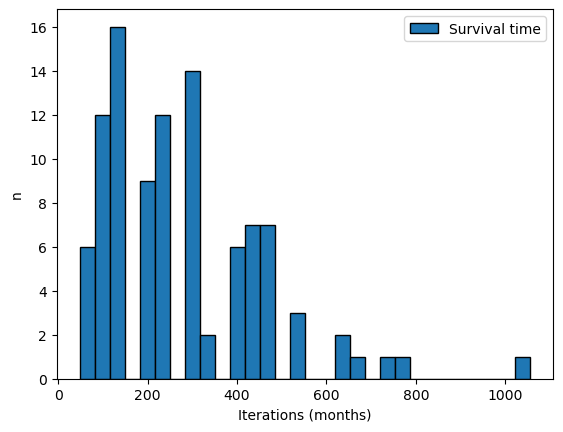

In [79]:
lifetimes = np.zeros(n_sims)
for i in range(n_sims):
    lifetimes[i] = (len(W[i])-1)*48

plt.hist(lifetimes,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 13

In [ ]:
# Transitions matrix
Q0 = np.array([
    [0, 0.01, 0.01, 0.01, 0.001],
    [0, 0, 0.01, 0.01, 0.01],
    [0, 0, 0, 0.01, 0.01],
    [0, 0, 0, 0, 0.01],
    [0, 0, 0, 0, 0]
])

for i in range(4):
    Q0[i,i] = -np.sum(Q0[i])

converged = False
tol = 1e-3
max_iter = 100
iter = 0

Qk = Q0

while (not converged):

    Nij = np.zeros((5,5))
    Si = np.zeros(5)

    for i in range(len(W)):

        accepted = False

        while (not accepted):
            # Inital parameters
            curr_state = 0
            t = 0
            n_observed = 0
            obs = [0]

            ts = [0]
            states = [0]

            # Transition to states until death
            while True:
                possible_states = [0,1,2,3,4]
                possible_states.pop(curr_state)

                t_new = rng.exponential(-1/Q[curr_state,curr_state])
                t += t_new

                new_state = rng.choice(a=possible_states, p=-1*(Qk[curr_state,possible_states])/(Qk[curr_state,curr_state]))

                ts.append(t_new)
                states.append(new_state)

                new_n_observed = int(t/48)

                if (new_n_observed != n_observed):
                    for m in range(int(new_n_observed - n_observed)):
                        obs.append(curr_state)
                    n_observed = new_n_observed

                
                # If state is the last state (death) then stop
                if (new_state == 4):
                    obs.append(4)
                    break
                
                # Update current state
                curr_state = new_state

            same = True
            for j in range(len(W[i])):
                if (obs[j] != W[i][j]):
                    same = False
                    break

            accepted = same

        for l in range(len(states)-1):
            Nij[states[l], states[l+1]] += 1
            Si[states[l]] += ts[l+1]

    new_Q = np.zeros((5,5))

    for n in range(4):
        for o in range(5):
            if (Nij[n,o] == 0):
                new_Q[n,o] = 0
            else:
                new_Q[n,o] = Nij[n,o] / Si[n]

    for k in range(4):
        new_Q[k,k] = -np.sum(new_Q[k])

    iter += 1

    converged = np.max(np.abs(Qk - new_Q)) <= tol

    Qk = new_Q

    print('Performed one iteration, new Q is:')
    print(Qk)

    if (iter >= max_iter):
        break

Performed one iteration, new Q is:
[[-0.00841621  0.00454475  0.00336648  0.00025249  0.00025249]
 [ 0.         -0.01668637  0.00370808  0.00525312  0.00772517]
 [ 0.          0.         -0.0091818   0.00388461  0.00529719]
 [ 0.          0.          0.         -0.00909473  0.00909473]
 [ 0.          0.          0.          0.          0.        ]]
Performed one iteration, new Q is:
[[-8.31661929e-03  5.15630396e-03  2.91081675e-03  8.31661929e-05
   1.66332386e-04]
 [ 0.00000000e+00 -1.80888636e-02  3.20931451e-03  5.83511729e-03
   9.04443179e-03]
 [ 0.00000000e+00  0.00000000e+00 -8.09551840e-03  3.16781155e-03
   4.92770685e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.77742802e-03
   8.77742802e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]]
Performed one iteration, new Q is:
[[-0.00839948  0.00537567  0.00268783  0.00016799  0.00016799]
 [ 0.         -0.01924192  0.00390851  0.00571244  0.00962096]
 [ 0.          0.         -